In [1]:
import pandas as pd

# 1. Cargamos los datos (¡asegúrate de que la ruta relativa sea correcta!)
df = pd.read_csv('../data/processed/openfmd_clean.csv')

# 2. Aplicamos la super máscara de filtros
# PISTA: recuerda usar símbolo '&' y encerrar todo en paréntesis
df_filtrado = df[(df['un_region'] == 'Africa') & (df['fmdv_positive'] == 'Yes')]

# Para ver qué tal nos fue:
print("Nos quedaron", len(df_filtrado), "registros en África")



KeyError: 'un_region'

In [2]:
import pandas as pd

# 1. Cargar datos desde la ruta correcta
df = pd.read_csv('../data/processed/openfmd_clean.csv')

# 2. Crear nuestras reglas de oro (cada regla en su propia cajita)
es_africa = (df['un_region'] == 'Africa')
es_positivo = (df['fmdv_positive'] == 'Yes')
es_despues_del_2000 = (df['date_sampling'] >= 2000)
es_antes_del_2025 = (df['date_sampling'] <= 2025)

# 3. ¡Aplicamos la purga! Le pasamos a Pandas todas las condiciones sumadas con el "&"
df_filtrado = df[es_africa & es_positivo & es_despues_del_2000 & es_antes_del_2025]

# 4. La línea maestra: Agrupar por país, contar los positivos, y ordenar de mayor a menor
top_paises = df_filtrado.groupby('country')['fmdv_positive'].count().sort_values(ascending=False)

# 5. Mostrar los 5 principales del ranking
print("--- RANKING TOP 5 DE ÁFRICA ---")
print(top_paises.head(5))


--- RANKING TOP 5 DE ÁFRICA ---
country
Egipto     5
Kenia      5
Etiopía    4
Nigeria    3
Sudán      3
Name: fmdv_positive, dtype: int64


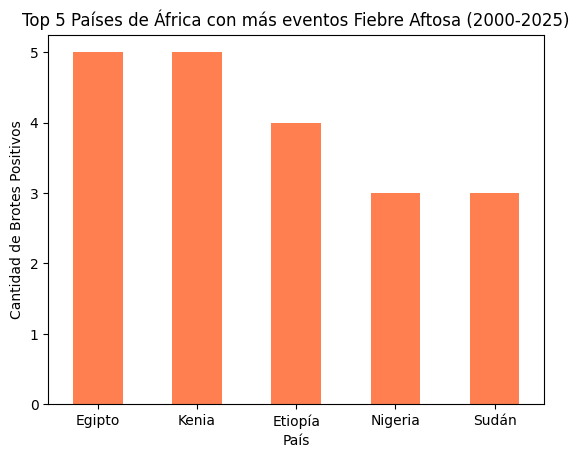

In [3]:
import matplotlib.pyplot as plt

# Le pedimos solo los 5 primeros (head) y le decimos qué TIPO de gráfica queremos

top_paises.head(5).plot(kind='bar', color='coral')

# Cosmetología científica
plt.title('Top 5 Países de África con más eventos Fiebre Aftosa (2000-2025)')
plt.ylabel('Cantidad de Brotes Positivos')
plt.xlabel('País')
plt.xticks(rotation=0)

# Revelamos el lienzo
plt.show()


### 3. Estadísticas Descriptivas Básicas
A continuación, vamos a calcular algunas medidas de tendencia central y dispersión para entender mejor cómo se distribuyen nuestros datos en el tiempo.

In [ ]:
# Vamos a ver la estadística descriptiva del año de muestreo (date_sampling)
print("--- ESTADÍSTICAS DEL AÑO DE MUESTREO ---")
print("Promedio (Media):", df_filtrado['date_sampling'].mean())
print("Mediana:", df_filtrado['date_sampling'].median())
print("Mínimo:", df_filtrado['date_sampling'].min())
print("Máximo:", df_filtrado['date_sampling'].max())
print("Desviación Estándar:", df_filtrado['date_sampling'].std())


### 4. Agrupamiento de Datos (Data Binning)
Para analizar mejor las tendencias a lo largo del tiempo, podemos agrupar los años de muestreo en **décadas** usando `pd.cut`.

In [ ]:
# Definimos los límites (bins) y las etiquetas (labels) para las décadas
bins = [1999, 2009, 2019, 2029]
labels = ['2000s', '2010s', '2020s']

# Creamos una nueva columna con la década correspondiente
df_filtrado_copy = df_filtrado.copy()
df_filtrado_copy['decada'] = pd.cut(df_filtrado_copy['date_sampling'], bins=bins, labels=labels)

# Contamos cuántos brotes hubo por década
brotes_por_decada = df_filtrado_copy['decada'].value_counts().sort_index()

print("--- BROTES POSITIVOS POR DÉCADA EN ÁFRICA ---")
print(brotes_por_decada)

# Visualizamos esto con un gráfico de pastel
brotes_por_decada.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribución de Brotes por Década')
plt.ylabel('')
plt.show()
